In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

In [2]:
from sklearn.datasets import fetch_openml
x, y = fetch_openml('mnist_784',return_X_y=True, version=1)
x=np.array(x)

In [3]:
x.shape

(70000, 784)

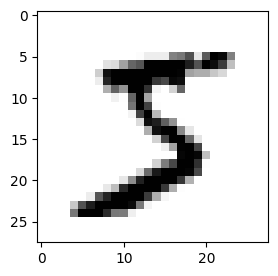

In [4]:
plt.figure(figsize=(3,3))
plt.imshow(x[0].reshape(28,28),cmap=mpl.cm.binary)
plt.show()

In [5]:
from sklearn.decomposition import PCA

pca=PCA(n_components=0.95)
z=pca.fit_transform(x)

In [6]:
pca.n_components_

np.int64(154)

In [7]:
np.sum(pca.explained_variance_ratio_)

np.float64(0.9503499702078614)

In [8]:
x.shape, z.shape

((70000, 784), (70000, 154))

In [9]:
wd=pca.components_.T
wd.shape

(784, 154)

In [10]:
s2=pca.explained_variance_
len(s2)

154

In [12]:
xr=pca.inverse_transform(z)

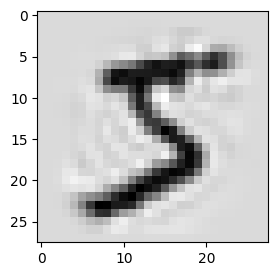

In [13]:
plt.figure(figsize=(3,3))
plt.imshow(xr[0].reshape(28,28),cmap=mpl.cm.binary)
plt.show()

In [16]:
rnd_pca=PCA(n_components=154, svd_solver='randomized',random_state=1)
z_rnd=rnd_pca.fit_transform(x)

In [17]:
xr_rnd=rnd_pca.inverse_transform(z_rnd)

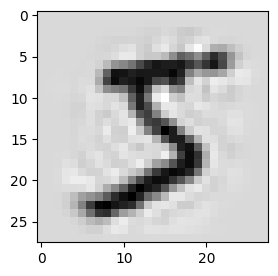

In [18]:
plt.figure(figsize=(3,3))
plt.imshow(xr_rnd[0].reshape(28,28),cmap=mpl.cm.binary)
plt.show()

In [19]:
from sklearn.decomposition import IncrementalPCA

inc_pca=IncrementalPCA(n_components=154,batch_size=700)
z_inc=inc_pca.fit_transform(x)

In [20]:
xr_inc=inc_pca.inverse_transform(z_inc)

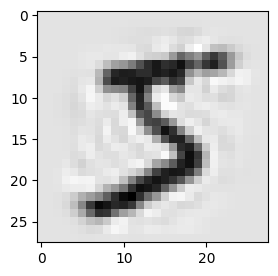

In [21]:
plt.figure(figsize=(3,3))
plt.imshow(xr_inc[0].reshape(28,28),cmap=mpl.cm.binary)
plt.show()